In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


**Data Handling & Preprocessing**

In [2]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

trainset = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(trainset, batch_size=128, shuffle=True,  num_workers=2)
test_loader  = DataLoader(testset,  batch_size=256, shuffle=False, num_workers=2)

classes = ['plane','car','bird','cat','deer','dog','frog','horse','ship','truck']

100%|██████████| 170M/170M [00:18<00:00, 9.35MB/s]


**CNN Architecture Design**

In [3]:
class CIFAR_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(64),
            nn.Conv2d(64,64,3,padding=1), nn.ReLU(), nn.BatchNorm2d(64),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.BatchNorm2d(128),
            nn.Conv2d(128,128,3,padding=1), nn.ReLU(), nn.BatchNorm2d(128),
            nn.MaxPool2d(2),

            nn.Conv2d(128,256,3,padding=1), nn.ReLU(), nn.BatchNorm2d(256),
            nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.head(x)

model = CIFAR_CNN().to(device)

**Training Function**

In [4]:
def train_model(model, epochs=8, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"[{epoch+1:2d}/{epochs}]  loss: {total_loss/len(train_loader):.4f}")
    return model

In [5]:
model = train_model(model, epochs=20, lr=0.001)

[ 1/20]  loss: 1.4412
[ 2/20]  loss: 0.9620
[ 3/20]  loss: 0.7865
[ 4/20]  loss: 0.6810
[ 5/20]  loss: 0.6153
[ 6/20]  loss: 0.5647
[ 7/20]  loss: 0.5198
[ 8/20]  loss: 0.4909
[ 9/20]  loss: 0.4659
[10/20]  loss: 0.4358
[11/20]  loss: 0.4222
[12/20]  loss: 0.3981
[13/20]  loss: 0.3866
[14/20]  loss: 0.3646
[15/20]  loss: 0.3626
[16/20]  loss: 0.3400
[17/20]  loss: 0.3338
[18/20]  loss: 0.3200
[19/20]  loss: 0.3061
[20/20]  loss: 0.3042


In [9]:
# For Evaluation

@torch.no_grad()
def evaluate(model, loader=test_loader):
    model.eval()
    preds, trues = [], []
    for x, y in loader:
        x = x.to(device)
        out = model(x)
        pred = out.argmax(dim=1).cpu().numpy()
        preds.extend(pred)
        trues.extend(y.numpy())
    acc = accuracy_score(trues, preds)
    print(f"Test accuracy: {acc*100:.2f}%")
    return np.array(preds), np.array(trues)

# print("MLP:")
# _ = evaluate(mlp)

# print("\nCNN:")
# preds, trues = evaluate(cnn)

preds, trues = evaluate(model)

# Per-class
correct = np.zeros(10)
total   = np.zeros(10)
for p,t in zip(preds, trues):
    total[t] += 1
    if p == t: correct[t] += 1

print("\nClass-wise accuracy:")
for i in range(10):
    print(f"{classes[i]:8} : {correct[i]/total[i]*100:5.1f}%")

Test accuracy: 87.90%

Class-wise accuracy:
plane    :  86.6%
car      :  95.7%
bird     :  81.3%
cat      :  75.2%
deer     :  87.5%
dog      :  87.8%
frog     :  91.1%
horse    :  87.4%
ship     :  93.2%
truck    :  93.2%


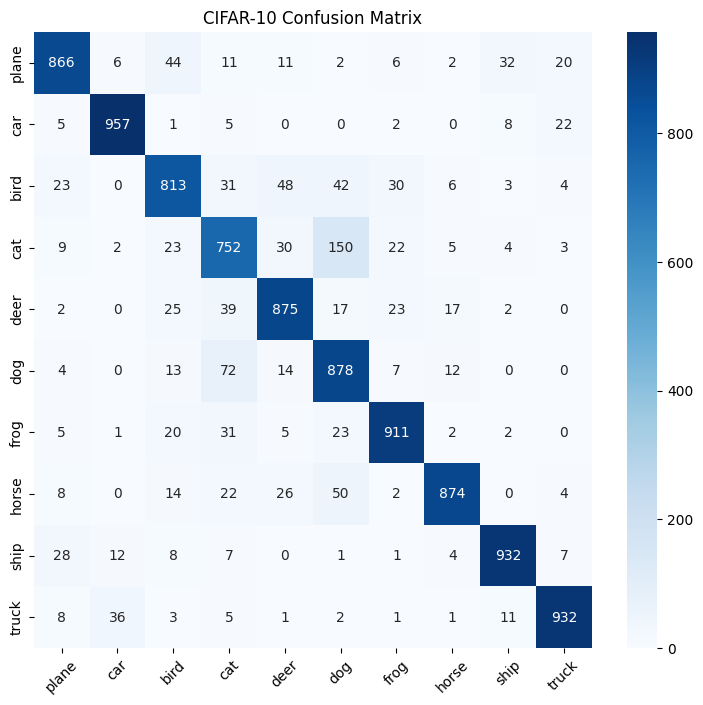

In [10]:
# Confusion matrix
cm = confusion_matrix(trues, preds)
plt.figure(figsize=(9,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xticks(rotation=45)
plt.title("CIFAR-10 Confusion Matrix")
plt.show()